<a href="https://colab.research.google.com/github/Laere11/Laere11/blob/Batteries/041425_fordfocusev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Summary Table of Measurements Since 03/12/25
The table below shows the key metrics at full‐charge (but unbalanced) conditions on various dates since the 03/12/25 balancing event. (“Days Since Balancing” is calculated from 03/12/25.)

Date	Days Since Balancing	Pack Voltage (V)	Avg Cell Voltage (V)	Cell #13 Voltage (V)	Voltage Range (mV)
03/12/25	0	–	~4.06*	~4.06*	~0
03/23/25	11	349.0927	4.0592	4.0196	~42
04/04/25	23	349.0524	4.0587	3.9831	~80
04/14/25	33	350.0754	4.0706	3.9702	~106
*For 03/12/25, the balanced condition is assumed to have set cell #13 at approximately 4.06 V (i.e. near the pack average).

Observations:
• Over time the voltage of cell #13 steadily declines, while the average cell voltage remains nearly unchanged.
• The voltage range (difference between the highest and lowest cell) increases—from about 42 mV on 03/23/25 to roughly 106 mV on 04/14/25.

2. Visualization & Linear Fit of Cell #13’s Voltage Decline
We now plot the voltage of cell #13 versus the number of days since the 03/12/25 balance. The data points are:

Day 0 (03/12/25): ~4.06 V

Day 11 (03/23/25): 4.0196 V

Day 23 (04/04/25): 3.9831 V

Day 33 (04/14/25): 3.9702 V

Using a linear regression, the best-fit line is computed to estimate the rate of voltage decline. (In the example below, the computed best-fit equation is approximately:

  V = 4.0545 – 0.00277 · (days since 3/12/25)

which suggests that cell #13 is declining by roughly 2.77 mV per day. Note that the regression may not pass exactly through the day 0 data point because the decline is not perfectly linear.)

Below is an example Python code snippet that creates the plot and calculates the best-fit line:

Best-fit linear equation: V = 4.0546 - 0.00277 * (days since 3/12/25)


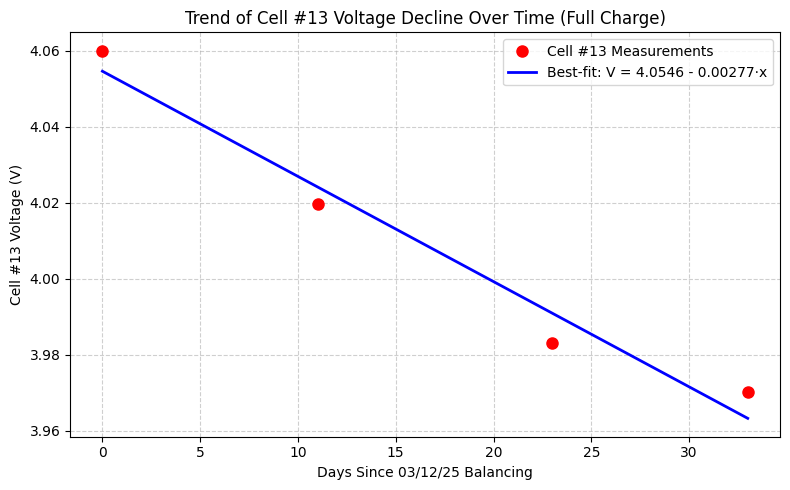

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Define the measurement dates relative to the balance date (03/12/25)
# Days since balancing and corresponding cell #13 voltages:
# Day 0: 4.06 V (assumed initial balanced value)
# Day 11: 4.0196 V (03/23/25)
# Day 23: 3.9831 V (04/04/25)
# Day 33: 3.9702 V (04/14/25)
days = np.array([0, 11, 23, 33])
voltages = np.array([4.06, 4.0196, 3.9831, 3.9702])

# Fit a linear regression (degree 1 polynomial)
coeffs = np.polyfit(days, voltages, 1)
slope, intercept = coeffs
best_fit_line = np.poly1d(coeffs)

# Generate x values for plotting the regression line
x_fit = np.linspace(0, 33, 100)
y_fit = best_fit_line(x_fit)

# Print the best-fit linear equation
print(f"Best-fit linear equation: V = {intercept:.4f} - {abs(slope):.5f} * (days since 3/12/25)")

# Plot the data and the regression line
plt.figure(figsize=(8, 5))
plt.plot(days, voltages, 'ro', markersize=8, label='Cell #13 Measurements')
plt.plot(x_fit, y_fit, 'b-', linewidth=2, label=f'Best-fit: V = {intercept:.4f} - {abs(slope):.5f}·x')
plt.xlabel("Days Since 03/12/25 Balancing")
plt.ylabel("Cell #13 Voltage (V)")
plt.title("Trend of Cell #13 Voltage Decline Over Time (Full Charge)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


When you run this code, it will display a scatter plot of the four measurement points for cell #13 and overlay the best-fit linear regression. According to the calculated parameters, cell #13’s voltage is declining at a rate of about 2.77 mV per day.

3. Final Characterization
The data from 03/12/25 through 04/14/25 reveal that even under full-charge conditions the cell voltage variation is progressively worsening. While most cells remain near the average (around 4.06–4.07 V), cell #13—already an outlier right after balancing—shows a marked decline from approximately 4.06 V at balance to 3.9702 V over 33 days. This increased imbalance (with the voltage range expanding to over 100 mV by 04/14/25) suggests that cell #13 is degrading at a faster rate than the rest of the pack, potentially warranting further investigation or preventive measures.

This comprehensive table and the accompanying visualization help you to monitor the degradation trend and evaluate whether the decline is linear or if additional nonlinear factors are at play over time.

Below is a complete Python script that reads the 04/14/25 dataset, builds a DataFrame for the 86 cells, computes the deviation (in millivolts) and Z–scores (using the provided overall average of 4.0706 V), and then generates four charts:

Histogram of Cell Voltages: Displays the distribution of cell voltages.

Scatter Plot (Cell Voltage vs. Cell Number): Plots each cell’s voltage versus its sequential cell number, with colors indicating the board.

Box Plot by Board: Compares the cell voltage distribution on each board to reveal board-specific variation.

Histogram of Z–Scores: Shows the spread of standardized deviations to spot outliers.

Below is the complete code:

Detailed Cell Data:
    cell  voltage  board  mV_from_avg   z_score
0      1   4.0729      0          2.3  0.202021
1      2   4.0673      0         -3.3 -0.289856
2      3   4.0709      0          0.3  0.026351
3      4   4.0641      0         -6.5 -0.570929
4      5   4.0658      0         -4.8 -0.421609
..   ...      ...    ...          ...       ...
81    82   4.0735      6          2.9  0.254722
82    83   4.0723      7          1.7  0.149320
83    84   4.0689      7         -1.7 -0.149320
84    85   4.0687      7         -1.9 -0.166887
85    86   4.0687      7         -1.9 -0.166887

[86 rows x 5 columns]


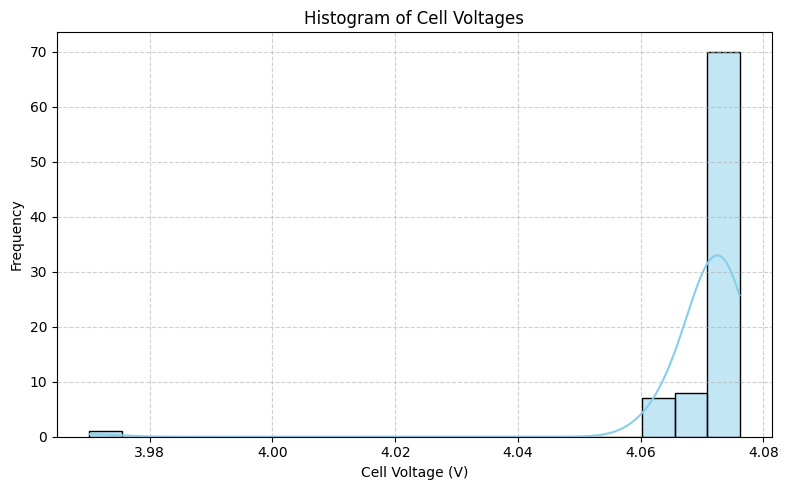

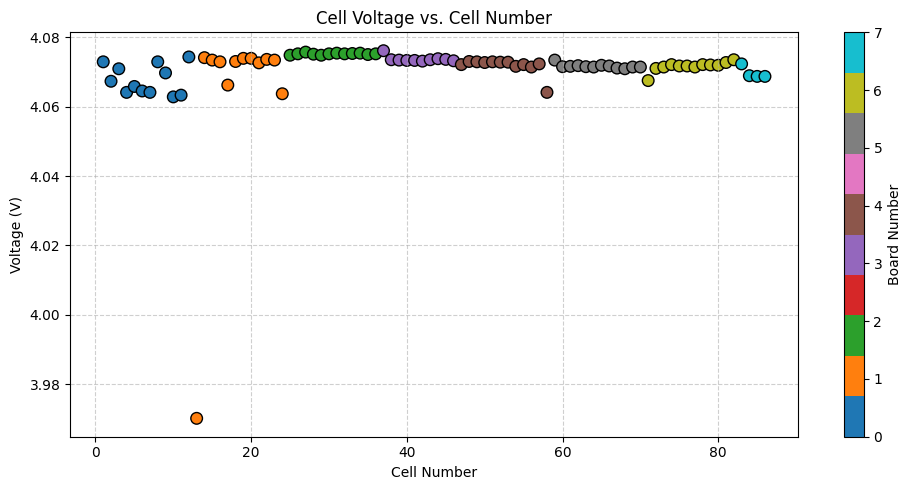

<ipython-input-2-3eda2ee25f7d>:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='board', y='voltage', data=df, palette="pastel")


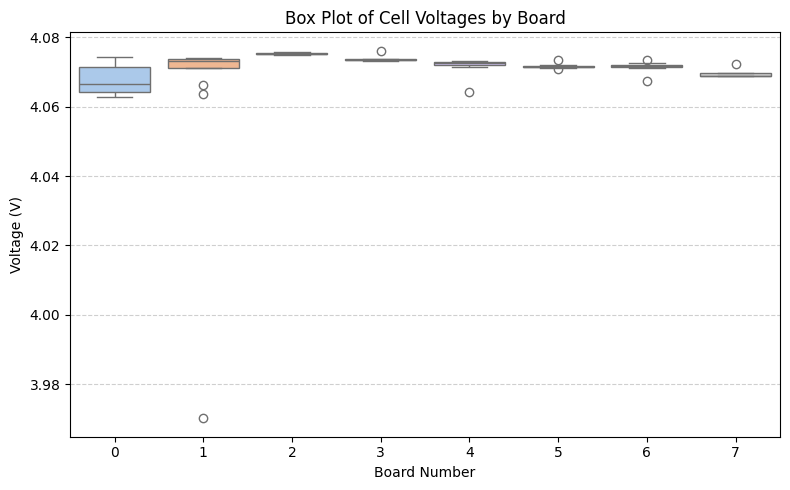

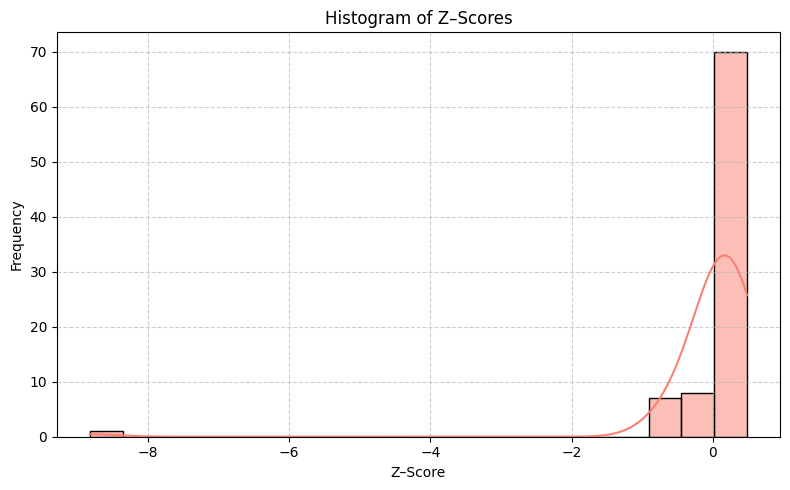

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# Data Setup for 04/14/25
# ---------------------------
# Each board’s cell voltages (86 cells in total)
board0 = [4.0729, 4.0673, 4.0709, 4.0641, 4.0658, 4.0645, 4.0641, 4.0729, 4.0697, 4.0628, 4.0633, 4.0743]
board1 = [3.9702, 4.0741, 4.0734, 4.0729, 4.0662, 4.0730, 4.0739, 4.0739, 4.0726, 4.0736, 4.0734, 4.0637]
board2 = [4.0748, 4.0752, 4.0757, 4.0751, 4.0748, 4.0752, 4.0754, 4.0752, 4.0753, 4.0754, 4.0750, 4.0752]
board3 = [4.0761, 4.0735, 4.0734, 4.0733, 4.0733, 4.0731, 4.0735, 4.0738, 4.0736, 4.0732]
board4 = [4.0721, 4.0730, 4.0729, 4.0727, 4.0729, 4.0728, 4.0728, 4.0716, 4.0721, 4.0714, 4.0723, 4.0641]
board5 = [4.0734, 4.0715, 4.0716, 4.0718, 4.0715, 4.0714, 4.0719, 4.0717, 4.0711, 4.0709, 4.0714, 4.0714]
board6 = [4.0675, 4.0710, 4.0714, 4.0721, 4.0717, 4.0717, 4.0714, 4.0721, 4.0720, 4.0719, 4.0727, 4.0735]
board7 = [4.0723, 4.0689, 4.0687, 4.0687]

# Concatenate all board data into one list
voltages = board0 + board1 + board2 + board3 + board4 + board5 + board6 + board7

# Create a list of board numbers corresponding to each cell (boards 0 through 7)
boards = (
    [0]*len(board0) +
    [1]*len(board1) +
    [2]*len(board2) +
    [3]*len(board3) +
    [4]*len(board4) +
    [5]*len(board5) +
    [6]*len(board6) +
    [7]*len(board7)
)

# Create a sequential list of cell numbers (1-indexed)
cells = list(range(1, len(voltages) + 1))

# Given overall average (avgV) from header:
avgV = 4.0706

# ---------------------------
# Build DataFrame & Compute Metrics
# ---------------------------
df = pd.DataFrame({
    'cell': cells,
    'voltage': voltages,
    'board': boards
})

# Compute overall standard deviation (σ) from the dataset
sigma = df['voltage'].std()

# Compute additional metrics:
# - mV from average: (voltage – avgV)*1000
# - Z–score: (voltage – avgV)/σ
df['mV_from_avg'] = (df['voltage'] - avgV) * 1000  # in millivolts
df['z_score'] = (df['voltage'] - avgV) / sigma

# Print the detailed cell data (table view)
print("Detailed Cell Data:")
print(df)

# ---------------------------
# 3. Charts & Visualizations
# ---------------------------

# Chart 1: Histogram of Cell Voltages
plt.figure(figsize=(8, 5))
sns.histplot(df['voltage'], bins=20, kde=True, color='skyblue')
plt.xlabel("Cell Voltage (V)")
plt.ylabel("Frequency")
plt.title("Histogram of Cell Voltages")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Chart 2: Scatter Plot (Cell Voltage vs. Cell Number)
plt.figure(figsize=(10, 5))
scatter = plt.scatter(df['cell'], df['voltage'], c=df['board'], cmap="tab10", s=70, edgecolor='k')
plt.xlabel("Cell Number")
plt.ylabel("Voltage (V)")
plt.title("Cell Voltage vs. Cell Number")
plt.colorbar(scatter, label="Board Number")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Chart 3: Box Plot by Board
plt.figure(figsize=(8, 5))
# Note: We're using the 'board' column for grouping.
sns.boxplot(x='board', y='voltage', data=df, palette="pastel")
plt.xlabel("Board Number")
plt.ylabel("Voltage (V)")
plt.title("Box Plot of Cell Voltages by Board")
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Chart 4: Histogram of Z–Scores
plt.figure(figsize=(8, 5))
sns.histplot(df['z_score'], bins=20, kde=True, color='salmon')
plt.xlabel("Z–Score")
plt.ylabel("Frequency")
plt.title("Histogram of Z–Scores")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Explanation
Data Processing:
The code first defines the voltage matrices for each board and creates a DataFrame with 86 rows corresponding to each cell’s data. The overall average (avgV) is set to 4.0706 V. The DataFrame also calculates:

The difference from average in millivolts (mV_from_avg).

The Z–score for each cell (z_score).

Chart 1: The histogram visualizes the frequency distribution of the cell voltages.

Chart 2: The scatter plot shows how cell voltage varies along the sequential cell numbers with color-coding by board.

Chart 3: The box plot helps to compare the voltage distributions across the different boards.

Chart 4: The histogram of Z–scores displays the spread of standardized voltage deviations, making outliers easy to spot.

When you run this script, you’ll see each of these visualizations, which together provide a thorough exploration of the 04/14/25 dataset's cell voltage distribution and highlight any board-specific or outlier behaviors.